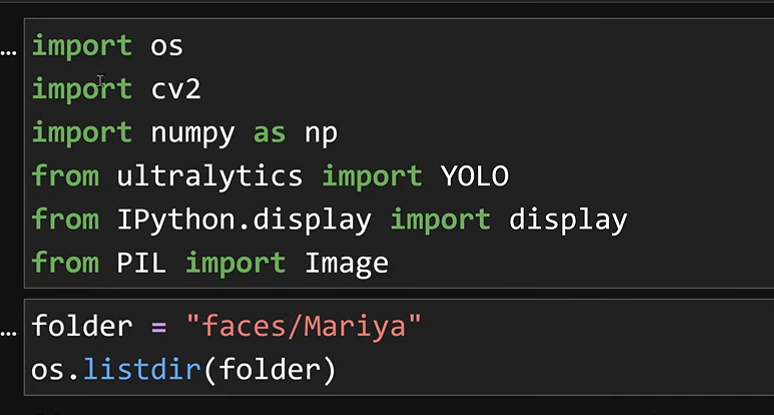

In [3]:
import os, cv2, numpy as np 

from ultralytics import YOLO
from IPython.display import display
from PIL import Image

In [3]:
folder = "/home/alireza/3D_Streaming/Yolo_CPUGPU/alireza_photos"
files = os.listdir(folder)

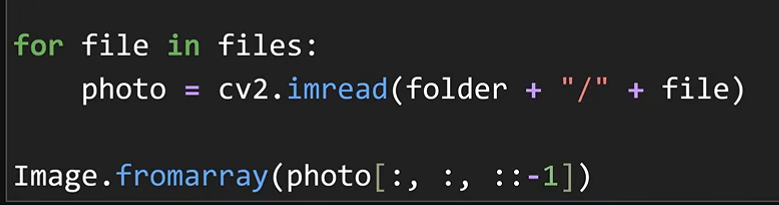

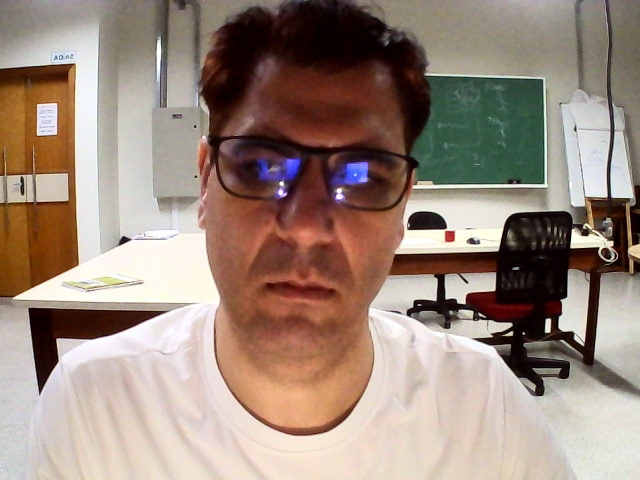

In [4]:
for file in files:
    photo = cv2.imread(folder + "/" + file)

Image.fromarray(photo[:,:,::-1]) # show the image in the notebook from the folder

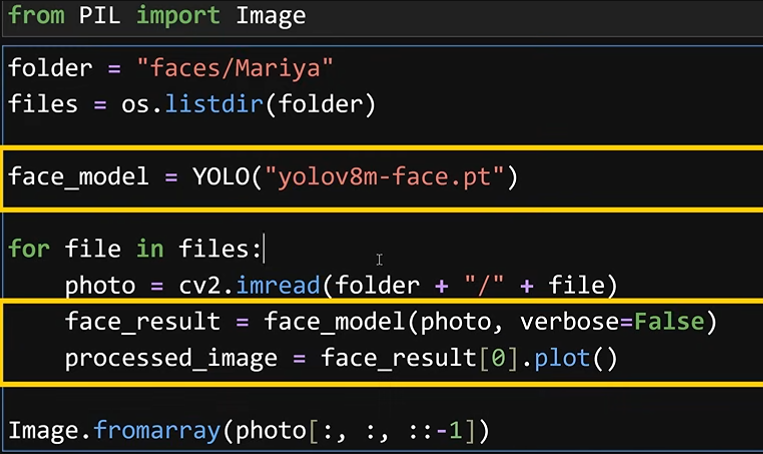

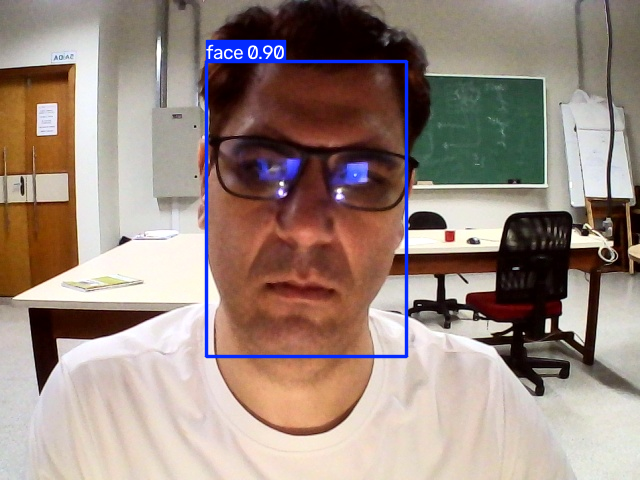

In [5]:
face_model = YOLO("/home/alireza/3D_Streaming/Yolo_CPUGPU/yolov8m-face.pt") # load a pretrained model (recommended for training)
    
for file in files:
    photo = cv2.imread(folder + "/" + file)
    face_results = face_model(photo, verbose=False) # predict on an image
    processed_image = face_results[0].plot() # draw boxes and labels on the image


Image.fromarray(processed_image[:,:,::-1]) # show the image in the notebook from the  processed image (expected: Blue rectangle around the face)

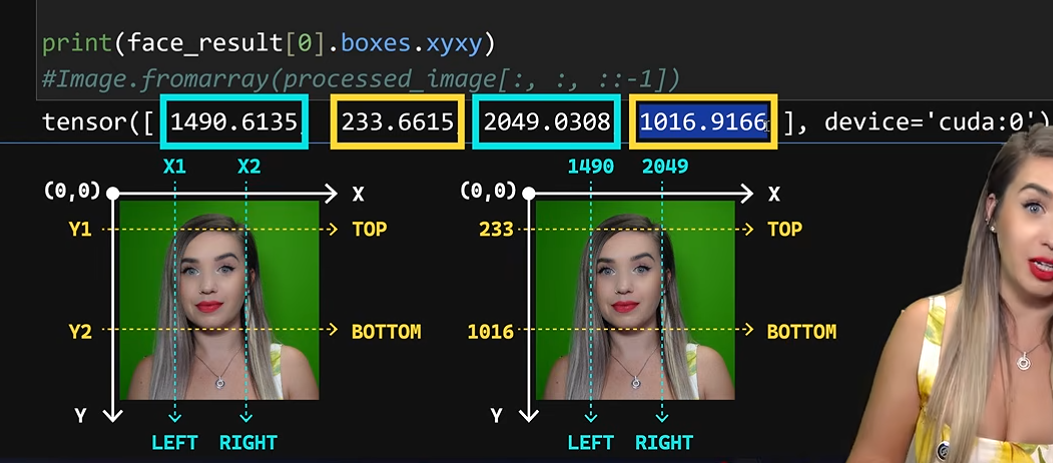

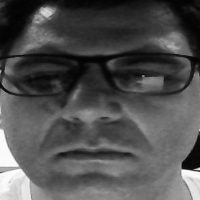

In [21]:
## uv add opencv-contrib-python

face_model = YOLO("/home/alireza/3D_Streaming/Yolo_CPUGPU/yolov8m-face.pt") # load a pretrained model (recommended for training)
face_recognizer = cv2.face.LBPHFaceRecognizer_create() # create a face recognizer object (Local Binary Pattern History (LBPH))
faces = []
labels = []

folders = {0: "/home/alireza/3D_Streaming/Yolo_CPUGPU/alireza_photos", 1:"/home/alireza/3D_Streaming/Yolo_CPUGPU/Maria_photos"}

for label, folder in folders.items():
    files = os.listdir(folder)
    for file in files:
        photo = cv2.imread(folder + "/" + file)
        face_results = face_model(photo, verbose=False) # predict on an image
        processed_image = face_results[0].plot() # draw boxes and labels on the image

        left , top, right, bottom = face_results[0].boxes.xyxy[0].int()
        face = photo[top:bottom, left:right] # crop the face from the original image
        face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY) # convert the face to grayscale
        face = cv2.resize(face, (200, 200))
        faces.append(face) # append the cropped face to the list of faces
        labels.append(label) # append the label to the list of labels

face_recognizer.train(faces,np.array(labels)) # train the face recognizer on the cropped faces and labels
face_recognizer.write("/home/alireza/3D_Streaming/Yolo_CPUGPU/face_recognizer.yml") # save the trained face recognizer to a file
#print(face_results[0].boxes.xyxy) # print the bounding box coordinates of the detected faces
#Image.fromarray(faces[0][:,:,::-1]) # show the image in the notebook from the  processed image (expected: Blue rectangle around the face)
Image.fromarray(faces[0])

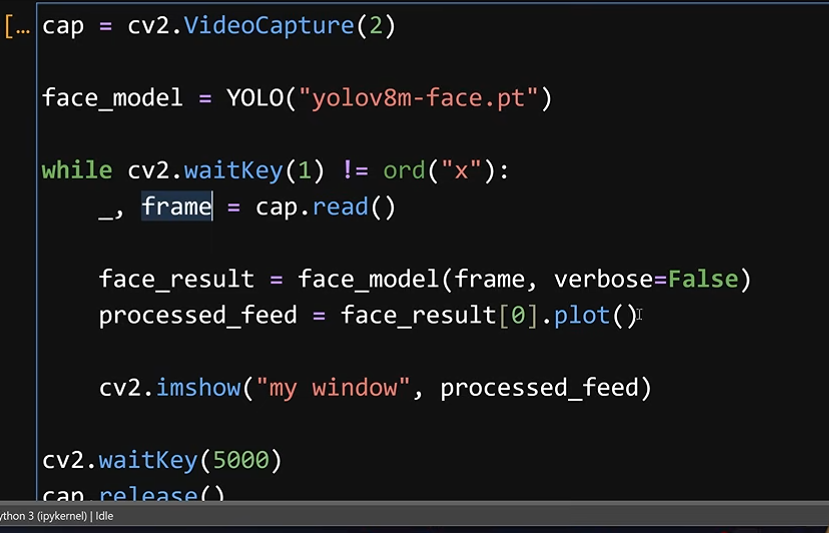

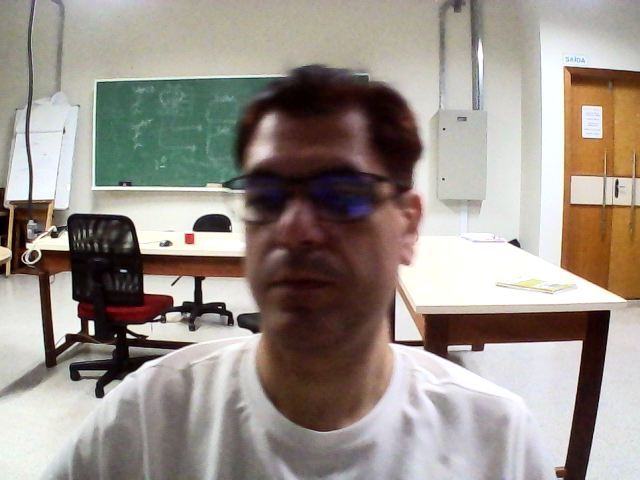

In [9]:
import time
from IPython.display import display
from PIL import Image

if "cap" in globals() and cap is not None:
    cap.release()

cap = cv2.VideoCapture("/dev/video0", cv2.CAP_V4L2)
if not cap.isOpened():
    cap.release()
    raise RuntimeError("Could not open /dev/video0")

try:
    display_handle = None
    preview_until = time.monotonic() + 5
    while time.monotonic() < preview_until:
        ret, frame = cap.read()
        if not ret:
            raise RuntimeError("Camera opened but no frame could be captured")

        preview = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if display_handle is None:
            display_handle = display(preview, display_id=True)
        else:
            display_handle.update(preview)
        time.sleep(0.05)
finally:
    cap.release()